# Next‑hour traffic forecasting (simple models)

In this notebook I build a first forecasting baseline for the two‑month
traffic cleaned dataset ("traffic_2months_clean.ipynb").

The goal is to predict the total traffic for the **next time step**
using only simple features:

- time of day (hour),
- day of the week,
- whether it is weekend or not,
- the total traffic at a few previous time steps (lag features).

I compare three models:

1. Naive baseline: `next_total = current_total`
2. Linear regression
3. Random Forest regressor




In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

In [73]:
clean_path = "../data/processed/traffic_2months_clean.csv"

df = pd.read_csv(clean_path)
print(df.shape)
df.head()

(5952, 9)


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal


In [74]:
df.info() #behaves as expected 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB


In [75]:
parsed_time = pd.to_datetime(df["Time"], format="%I:%M:%S %p")
df["hour"] = parsed_time.dt.hour
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_to_idx = {day: i for i, day in enumerate(day_order)}
df["day_index"] = df["Day of the week"].map(day_to_idx)
df["is_weekend"] = df["day_index"].isin([5, 6]).astype(int)
df[["Time", "Day of the week", "hour", "day_index", "is_weekend"]].head()

,Time,Day of the week,hour,day_index,is_weekend
0,12:00:00 AM,Tuesday,0,1,0
1,12:15:00 AM,Tuesday,0,1,0
2,12:30:00 AM,Tuesday,0,1,0
3,12:45:00 AM,Tuesday,0,1,0
4,1:00:00 AM,Tuesday,1,1,0


In [76]:
df = df.sort_values(["Date", "hour"]).reset_index(drop=True)
# lag features for total
df["total_lag1"] = df["Total"].shift(1)
df["total_lag2"] = df["Total"].shift(2)
df["total_lag3"] = df["Total"].shift(3)
# next time step's total
df["next_total"] = df["Total"].shift(-1)
df[["Time", "Total", "total_lag1", "total_lag2", "total_lag3", "next_total"]].head(10)

,Time,Total,total_lag1,total_lag2,total_lag3,next_total
0,12:00:00 AM,45,NaN,NaN,NaN,52.0
1,12:15:00 AM,52,45.0,NaN,NaN,50.0
2,12:30:00 AM,50,52.0,45.0,NaN,51.0
3,12:45:00 AM,51,50.0,52.0,45.0,48.0
4,12:00:00 AM,48,51.0,50.0,52.0,45.0
5,12:15:00 AM,45,48.0,51.0,50.0,39.0
6,12:30:00 AM,39,45.0,48.0,51.0,33.0
7,12:45:00 AM,33,39.0,45.0,48.0,45.0
8,1:00:00 AM,45,33.0,39.0,45.0,34.0
9,1:15:00 AM,34,45.0,33.0,39.0,43.0


Rows at the very beginning and very end do not have complete lag/target
information (because of the `shift` operations). I remove them so that
every row used for training has all required values.

In [77]:
required_cols = ["total_lag1", "total_lag2", "total_lag3", "next_total"]
before = len(df)
df_model = df.dropna(subset=required_cols).reset_index(drop=True)
after = len(df_model)
print(f"Rows before dropping NaNs: {before}")
print(f"Rows after  dropping NaNs: {after}")
print(f"Dropped {before - after} rows")

Rows before dropping NaNs: 5952
Rows after  dropping NaNs: 5948
Dropped 4 rows


In [78]:
# build a prper datetime index from Date and Time
dt = pd.to_datetime(
    df_model["Date"].astype(str) + " " + df_model["Time"],
    format="%d %I:%M:%S %p"   # adjust format if needed
)
df_model["datetime"] = dt

## 3. Train/test split (time‑based)

Because this is time‑series data, I do **not** shuffle. I split the
dataset in chronological order:

- first 80% of the rows → training set
- last 20% → test set

This simulates training on past data and evaluating on future data.

In [79]:
feature_cols = [
    "hour","day_index","is_weekend","total_lag1","total_lag2","total_lag3",
]

target_col = "next_total"
X = df_model[feature_cols]
y = df_model[target_col]
n = len(df_model)
split_idx = int(0.8 * n)
X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]
print(f"Total samples: {n}")

print(f"Train samples: {len(X_train)}")
print(f"Test samples : {len(X_test)}")

Total samples: 5948
Train samples: 4758
Test samples : 1190


## 4. Baseline model – "next = current"

As a sanity check I start with a trivial baseline that simply predicts:

> `next_total = total_lag1`

This is equivalent to assuming that traffic stays the same from one time
step to the next. If more advanced models cannot beat this, something muust be
wrong

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [81]:
y_pred_baseline = X_test["total_lag1"].values
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
print("Baseline (next = current)")
print(f"MAE : {mae_baseline:.2f}")
print(f"RMSE: {rmse_baseline:.2f}")

Baseline (next = current)
MAE : 27.64
RMSE: 38.60


## 5. Linear regression model

Next I train a simple linear regression model on the same features.
the model learns one coefficient per feature and tries to fit a linear relationship between the features and
`next_total`

In [82]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print("lnear regression")
print(f"MAE : {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}\n")

print("baseline vs linear regression")
print(f"baseline MAE : {mae_baseline:.2f}")
print(f"linReg  MAE  : {mae_lr:.2f}")
print(f"baseline RMSE: {rmse_baseline:.2f}")
print(f"linReg  RMSE : {rmse_lr:.2f}")

lnear regression
MAE : 25.66
RMSE: 34.23

baseline vs linear regression
baseline MAE : 27.64
linReg  MAE  : 25.66
baseline RMSE: 38.60
linReg  RMSE : 34.23


## 6. Random Forest regressor

Finally I try a slightly more flexible model: a Random Forest regressor.

Random Forests can capture non‑linear relationships and interactions
between features. I keep the hyperparameters modest so the model is
still easy to train and reason about.

In [83]:
rf = RandomForestRegressor(
    n_estimators=200,max_depth=None,random_state=0,n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print("random forest")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}\n")

print("summary")
print("--------------------------")
print(f"baseline MAE : {mae_baseline:.2f}")
print(f"LinReg  MAE  : {mae_lr:.2f}")
print(f"RF      MAE  : {mae_rf:.2f}")
print()
print(f"baseline RMSE: {rmse_baseline:.2f}")
print(f"LinReg  RMSE : {rmse_lr:.2f}")
print(f"RF      RMSE : {rmse_rf:.2f}")

random forest
MAE : 19.50
RMSE: 26.81

summary
--------------------------
baseline MAE : 27.64
LinReg  MAE  : 25.66
RF      MAE  : 19.50

baseline RMSE: 38.60
LinReg  RMSE : 34.23
RF      RMSE : 26.81


## 7. Visualizing predictions on a sample window

Numbers are useful, but I also want to see how the predictions behave
over time. I plot actual vs predicted `next_total` for a small window in
the test period.

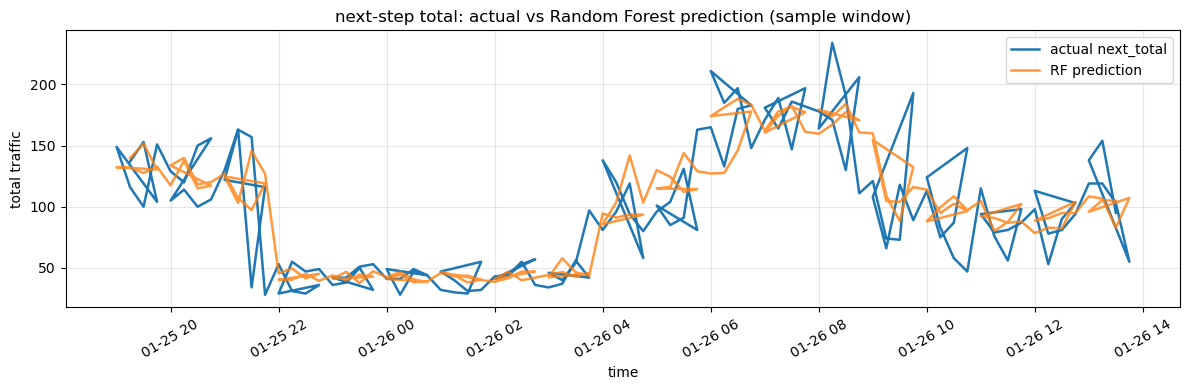

In [89]:
window = slice(0, 150) # first 150 points of the test set
time_window = df_model["datetime"].iloc[split_idx:].iloc[window]
y_true_window = y_test.iloc[window].values
y_pred_window = y_pred_rf[window]

plt.figure(figsize=(12, 4))
plt.plot(time_window, y_true_window, label="actual next_total", linewidth=1.8)
plt.plot(time_window, y_pred_window, label="RF prediction", linewidth=1.8, alpha=0.8)
plt.xlabel("time")
plt.ylabel("total traffic")
plt.title("next‑step total: actual vs Random Forest prediction (sample window)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


The blue line is the actual next‑step total traffic, while the orange line is the Random Forest prediction. The model captures the main structure of the signal: it tracks the nighttime low, the morning ramp‑up, and the midday plateau reasonably well. At sharp local spikes the prediction lags behind or smooths them out, which is typical for an ensemble model that averages over many trees using only a small set of lag and time‑of‑day features. Starting from the naive “next = current” predictor with MAE 27.64 and RMSE 38.60, the linear regression model already brings that down to 25.66 and 34.23, and the Random Forest with three lag features reaches 19.50 MAE and 26.81 RMSE on the last 20% of the time series. I also tried adding more lags, but the improvement was small, so I kept the model deliberately simple for clarity and speed. Overall, the forecast reduces random noise while preserving the daily pattern, which is acceptable for a first baseline model.
forecasting.ipynb